# Contrast limits with Ruffio method

Suppose you have a non-detection; or suppose you have a detection of a point source very accurately, and you can subtract that signal off the visibilities and you want to know if there is anything *else* in the data. How can you quantify what your detection limits would have been?

There are two methods widely in use in interferometry and this tutorial covers both of them:

- the Ruffio method, which is Bayesian. This calculates the posterior distribution for flux of a point source companion everywhere in a grid using the Laplace approximation, and uses this to put a posterior Nσ upper limit on any flux.
- the Absil method, which is frequentist, and relies on $\chi^2$ statistics to put a confidence interval on the data and report an upper limit.

In this tutorial we'll work through applying both methods to a nondetection.

First, let's import everything we need.

In [1]:
import sys
from pathlib import Path

import jax.numpy as jnp
import numpy as onp
import jax.scipy as jsp
import matplotlib.pyplot as plt
import pyoifits as oifits

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from drpangloss.models import OIData, BinaryModelCartesian
from drpangloss.grid_fit import (
    likelihood_grid,
    optimized_contrast_grid,
    laplace_contrast_uncertainty_grid,
    ruffio_upperlimit,
    absil_limits,
)
from drpangloss.plotting import (
    plot_contrast_limit_map,
    radial_limit_summary,
    plot_radial_limit_summary,
)

Now we will generate some synthetic data from pure noise, using a Fourier sampling similar to the JWST AMI mask.

In [2]:
rng = onp.random.default_rng(7)

fname = "NuHor_F480M.oifits"
ddir = "../data/"
data = oifits.open(ddir + fname)
try:
    data.verify("silentfix")
except AttributeError:
    pass

oidata = OIData(data)

# Pure-noise injection amplitude (1.0 uses nominal OIData uncertainties).
noise_amp = 1.0

sim_data = {
    "u": oidata.u,
    "v": oidata.v,
    "wavel": oidata.wavel,
    "vis": jnp.ones_like(oidata.vis)
    + noise_amp * jnp.array(rng.normal(size=oidata.vis.shape)) * oidata.d_vis,
    "d_vis": oidata.d_vis,
    "phi": noise_amp * jnp.array(rng.normal(size=oidata.phi.shape)) * oidata.d_phi,
    "d_phi": oidata.d_phi,
    "i_cps1": oidata.i_cps1,
    "i_cps2": oidata.i_cps2,
    "i_cps3": oidata.i_cps3,
    "v2_flag": oidata.v2_flag,
    "cp_flag": oidata.cp_flag,
}

oidata_sim = OIData(sim_data)

print('Noise amplitude: {:.2g}, Vis std: {:.2g}, Phi std: {:.2g}'.format(noise_amp, float(jnp.std(sim_data["vis"] - 1.0)), float(jnp.std(sim_data["phi"]))))

Noise amplitude: 1, Vis std: 0.00033, Phi std: 0.016


Next we declare the grid over which we're going to search for companions, and we will use this to initialize the flux level in each grid pixel around which we are going to expand the posterior / come up with confidence intervals. 

In [3]:
samples = {
    "dra": jnp.linspace(-250.0, 250.0, 61),
    "ddec": jnp.linspace(-250.0, 250.0, 61),
    "flux": 10 ** jnp.linspace(-5.0, -1.5, 50),
}

ll_cube = likelihood_grid(oidata_sim, BinaryModelCartesian, samples)
opt_flux = optimized_contrast_grid(oidata_sim, BinaryModelCartesian, samples)
best_idx = jnp.argmax(ll_cube, axis=2)

Let's run and visualize the results of the Ruffio method.

W0304 13:53:20.767323 3042460 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


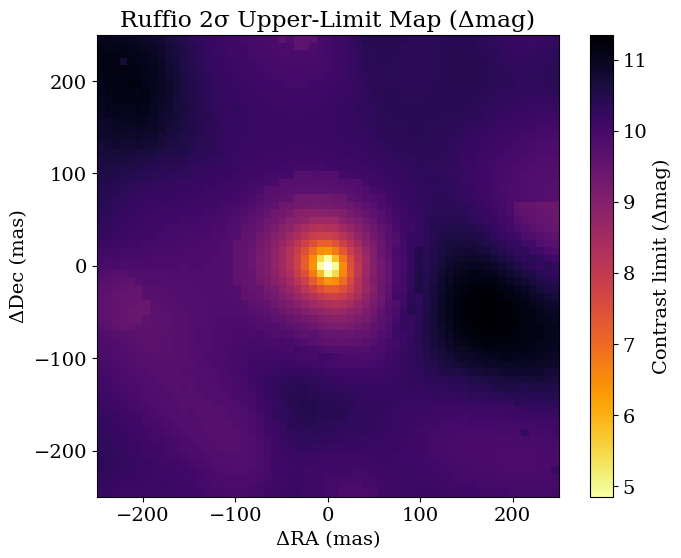

In [4]:

sigma_flux = laplace_contrast_uncertainty_grid(
    best_idx, oidata_sim, BinaryModelCartesian, samples
)

# Ruffio method at 2σ equivalent percentile
perc = jnp.array([jsp.stats.norm.cdf(2.0)])
ruffio_flat = ruffio_upperlimit(opt_flux.flatten(), sigma_flux.flatten(), perc)
ruffio_map = ruffio_flat.reshape(*opt_flux.shape, perc.shape[0])[:, :, 0]

# 2D contrast-limit maps (Δmag): Ruffio and Absil

dra_axis = onp.array(samples["dra"])
ddec_axis = onp.array(samples["ddec"])
ruffio_np = onp.array(ruffio_map)

plot_contrast_limit_map(
    ruffio_np,
    dra_axis,
    ddec_axis,
    truth=None,
    unit_mode="delta_mag",
    title="Ruffio 2σ Upper-Limit Map (Δmag)",
    cmap="inferno",
);

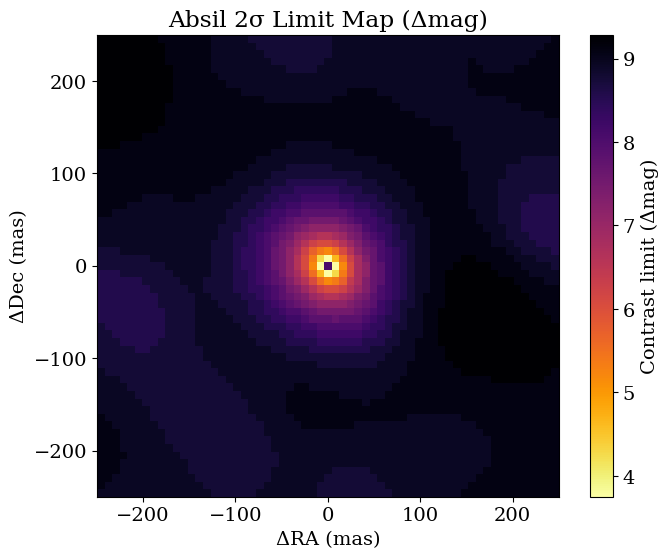

In [5]:

# Absil method at 2σ
absil_map = absil_limits(samples, oidata_sim, BinaryModelCartesian, sigma=2.0)

{
    "opt_flux_finite_frac": float(jnp.mean(jnp.isfinite(opt_flux))),
    "sigma_flux_finite_frac": float(jnp.mean(jnp.isfinite(sigma_flux))),
    "ruffio_finite_frac": float(jnp.mean(jnp.isfinite(ruffio_map))),
    "absil_finite_frac": float(jnp.mean(jnp.isfinite(absil_map))),
    "ruffio_median": float(jnp.nanmedian(ruffio_map)),
    "absil_median": float(jnp.nanmedian(absil_map)),
}
absil_np = onp.array(absil_map)


plot_contrast_limit_map(
    absil_np,
    dra_axis,
    ddec_axis,
    truth=None,
    unit_mode="delta_mag",
    title="Absil 2σ Limit Map (Δmag)",
    cmap="inferno",
);

We can visualize these as contrast curves, and plot these on the same axis. They come out to be pretty similar but not quite identical.

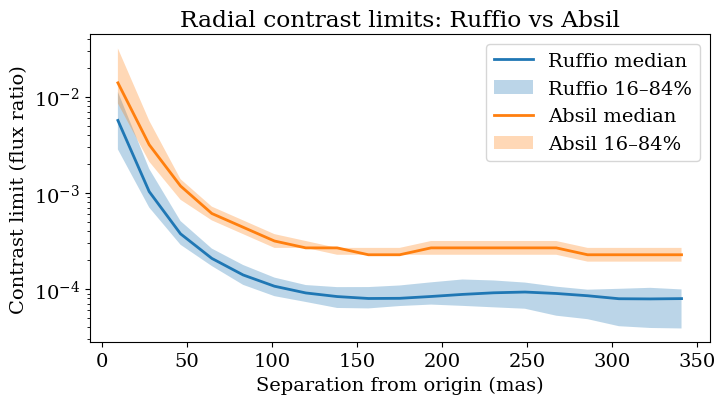

In [6]:
# Overplot Ruffio and Absil radial contrast curves on one axis
fig, ax = plt.subplots(figsize=(8, 4))

ruffio_radial_summary = radial_limit_summary(ruffio_map, dra_axis, ddec_axis)
absil_radial_summary = radial_limit_summary(absil_map, dra_axis, ddec_axis)

plot_radial_limit_summary(
    ruffio_radial_summary,
    unit_mode="flux_ratio",
    title="Radial contrast limits: Ruffio vs Absil",
    ax=ax,
)
ax.lines[-1].set_label("Ruffio median")
ax.collections[-1].set_label("Ruffio 16–84%")

plot_radial_limit_summary(
    absil_radial_summary,
    unit_mode="flux_ratio",
    title="Radial contrast limits: Ruffio vs Absil",
    ax=ax,
)
ax.lines[-1].set_label("Absil median")
ax.collections[-1].set_label("Absil 16–84%")

ax.set_xlabel("Separation from origin (mas)")
ax.legend(loc="best")